# TP4 - Bin Packing : Algorithmes population-based

Equipe n°4 • Année universitaire : 2025-2026

---

Ce notebook presente les methodes population-based implementees dans
`4_population_based/solver.py` pour le probleme de Bin Packing.

On etudie deux familles :

- **Genetic Algorithm (GA)** : population de solutions, selection, croisement,
  mutation, variantes memetic/island.
- **Ant Colony Optimization (ACO)** : construction probabiliste d'ordres
  d'objets a partir d'une matrice de pheromones.

Les resultats de tuning ACO sont lus depuis les fichiers CSV generes par
`tune_aco.py`. Le notebook peut aussi construire un CSV de comparaison
GA/ACO (`population_comparison.csv`) pour visualiser les deux algorithmes dans
le meme protocole.

---

## 1) Conception theorique

### 1.1 Representation commune

Une solution est representee par :

- le nombre total de bins utilises,
- l'affectation des objets a chaque bin,
- la charge finale de chaque bin.

La qualite est mesuree principalement par :

```text
gap = bins_used - ceil(total_weight / capacity)
```

Le gap compare la solution a une borne inferieure simple. Plus il est proche de
0, meilleure est la solution.

### 1.2 Genetic Algorithm

Le GA manipule une population de solutions. Chaque individu est une affectation
valide des objets aux bins.

Les operations principales sont :

- **selection tournoi** : choisir les meilleurs parents parmi quelques candidats,
- **UBX crossover** : recombiner des bins entiers issus des deux parents,
- **mutation** : appliquer un voisinage relocation/swap,
- **elitisme** : conserver les meilleurs individus d'une generation a l'autre.

Trois variantes sont disponibles dans le solver :

- `ga` : version de base,
- `ga memetic` : GA + recherche locale sur les enfants,
- `ga island` : populations separees avec migration periodique.

La variante memetic est souvent plus couteuse, car elle applique une recherche
locale de nombreuses fois.

### 1.3 Ant Colony Optimization

ACO construit d'abord un ordre d'objets, puis applique First-Fit dans cet ordre.

Chaque ant choisit le prochain objet selon :

```text
attractiveness(i, j) = pheromone[i][j]^alpha * heuristic[j]^beta
```

avec :

- `alpha` : poids de la pheromone,
- `beta` : poids de l'heuristique taille/capacite,
- `evaporation_rate` : vitesse d'oubli,
- `deposit_strength` : intensite du depot de pheromone par les bonnes solutions.

Le tuning cherche donc un compromis entre exploration, exploitation et temps de
calcul.

---

## 2) Methodologie experimentale

Le tuning ACO est fait par **coordinate search** :

1. partir de `ACO_DEFAULTS`,
2. choisir un parametre,
3. tester toutes les valeurs de sa grille,
4. garder la meilleure valeur,
5. passer au parametre suivant.

On evite ainsi un full grid search tres couteux :

```text
4^8 = 65 536 combinaisons
```

contre environ :

```text
1 + 8 * 4 = 33 evaluations
```

par round de tuning.

Le critere de selection est lexicographique :

1. minimiser `avg_gap`,
2. minimiser `worst_dataset_avg_gap`,
3. maximiser `exact_hits`,
4. minimiser `avg_time`.

In [16]:
# -- Imports & path setup -----------------------------------------------------
%matplotlib inline

import os
import random
import sys
import time
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "4_population_based":
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_BASE_DIR = PROJECT_ROOT / "results" / "4_population_based"
RESULTS_DIR = RESULTS_BASE_DIR / "aco_tuning" / "parameters"
FIGURES_DIR = RESULTS_BASE_DIR / "aco_tuning" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MPLCONFIGDIR = PROJECT_ROOT / ".matplotlib-cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

sys.path.insert(0, str(PROJECT_ROOT / "4_population_based"))
from solver import BinPackingSolver

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)


def savefig(fig, filename):
    path = FIGURES_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    print(f"saved {path.relative_to(PROJECT_ROOT)}")

---

## 3) Chargement des logs CSV de tuning ACO

Les fichiers attendus sont :

- `aco_tuning_global.csv`,
- `aco_tuning_falkenauer_t.csv`,
- `aco_tuning_falkenauer_u.csv`,
- `aco_tuning_scholl_1.csv`,
- `aco_tuning_scholl_2.csv`,
- `aco_tuning_scholl_3.csv`.

In [17]:
csv_files = sorted(RESULTS_DIR.glob("aco_tuning_*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No ACO tuning CSV files found in {RESULTS_DIR}")

logs = []
for path in csv_files:
    df = pd.read_csv(path)
    df["source_file"] = path.name
    df["scope"] = path.stem.replace("aco_tuning_", "").replace("_", "-")
    logs.append(df)

aco_logs = pd.concat(logs, ignore_index=True)

numeric_cols = [
    "round", "runs", "avg_gap", "worst_dataset_avg_gap", "best_gap",
    "worst_gap", "exact_hits", "avg_time", "num_ants", "generations",
    "alpha", "beta", "evaporation_rate", "pheromone_init", "pheromone_min",
    "pheromone_max", "elite_ants", "local_search_steps", "deposit_strength",
]
for col in numeric_cols:
    if col in aco_logs:
        aco_logs[col] = pd.to_numeric(aco_logs[col], errors="coerce")

file_summary = (
    aco_logs.groupby(["scope", "source_file"], as_index=False)
    .agg(rows=("parameter", "size"), runs_per_eval=("runs", "max"))
    .sort_values(["scope", "source_file"])
)

display(file_summary)
display(aco_logs.head())

,scope,source_file,rows,runs_per_eval
0,falkenauer-t,aco_tuning_falkenauer_t.csv,33,3
1,falkenauer-u,aco_tuning_falkenauer_u.csv,33,6
2,global,aco_tuning_global.csv,33,24
3,scholl-1,aco_tuning_scholl_1.csv,33,3
4,scholl-2,aco_tuning_scholl_2.csv,33,9
5,scholl-3,aco_tuning_scholl_3.csv,33,3


,label,round,parameter,value,runs,avg_gap,worst_dataset_avg_gap,best_gap,worst_gap,exact_hits,avg_time,num_ants,generations,alpha,beta,evaporation_rate,pheromone_init,pheromone_min,pheromone_max,elite_ants,local_search_steps,deposit_strength,source_file,scope
0,ACO/falkenauer-t,0,initial,NaN,3,2.0,2.0,2,2,0,0.285413,16,80,1.0,3.0,0.2,1.0,0.01,6.0,3,40,1000.0,aco_tuning_falkenauer_t.csv,falkenauer-t
1,ACO/falkenauer-t,1,num_ants,10.0,3,2.0,2.0,2,2,0,0.199435,10,80,1.0,3.0,0.2,1.0,0.01,6.0,3,40,1000.0,aco_tuning_falkenauer_t.csv,falkenauer-t
2,ACO/falkenauer-t,1,num_ants,16.0,3,2.0,2.0,2,2,0,0.287743,16,80,1.0,3.0,0.2,1.0,0.01,6.0,3,40,1000.0,aco_tuning_falkenauer_t.csv,falkenauer-t
3,ACO/falkenauer-t,1,num_ants,24.0,3,2.0,2.0,2,2,0,0.405457,24,80,1.0,3.0,0.2,1.0,0.01,6.0,3,40,1000.0,aco_tuning_falkenauer_t.csv,falkenauer-t
4,ACO/falkenauer-t,1,num_ants,32.0,3,2.0,2.0,2,2,0,0.525738,32,80,1.0,3.0,0.2,1.0,0.01,6.0,3,40,1000.0,aco_tuning_falkenauer_t.csv,falkenauer-t


---

## 4) Reconstruction des meilleurs parametres ACO

Le CSV contient toutes les valeurs testees. Pour reconstruire le chemin de
tuning, on reprend le meilleur choix pour chaque bloc :

```text
(scope, round, parameter)
```

In [18]:
PARAM_COLS = [
    "num_ants", "generations", "alpha", "beta", "evaporation_rate",
    "pheromone_init", "pheromone_min", "pheromone_max", "elite_ants",
    "local_search_steps", "deposit_strength",
]

TUNED_PARAM_COLS = [
    "num_ants", "generations", "alpha", "beta", "evaporation_rate",
    "elite_ants", "local_search_steps", "deposit_strength",
]


def ranked_rows(df):
    return df.sort_values(
        ["avg_gap", "worst_dataset_avg_gap", "exact_hits", "avg_time"],
        ascending=[True, True, False, True],
        kind="stable",
    )


def select_winners(df):
    candidates = df[df["parameter"] != "initial"].copy()
    rows = []
    group_cols = ["source_file", "scope", "label", "round", "parameter"]
    for _, group in candidates.groupby(group_cols, sort=False):
        rows.append(ranked_rows(group).iloc[0])
    return pd.DataFrame(rows).reset_index(drop=True)


selected_steps = select_winners(aco_logs)
final_aco_rows = (
    selected_steps.sort_values(["source_file", "round"], kind="stable")
    .groupby("source_file", as_index=False)
    .tail(1)
    .sort_values("scope")
    .reset_index(drop=True)
)

final_cols = [
    "scope", "label", "runs", "avg_gap", "worst_dataset_avg_gap",
    "best_gap", "worst_gap", "exact_hits", "avg_time", *PARAM_COLS,
]

display(final_aco_rows[final_cols].round({
    "avg_gap": 3,
    "worst_dataset_avg_gap": 3,
    "avg_time": 3,
}))

global_aco_params = (
    final_aco_rows[final_aco_rows["scope"] == "global"][PARAM_COLS]
    .iloc[0]
    .dropna()
    .to_dict()
)
global_aco_params["num_ants"] = int(global_aco_params["num_ants"])
global_aco_params["generations"] = int(global_aco_params["generations"])
global_aco_params["elite_ants"] = int(global_aco_params["elite_ants"])
global_aco_params["local_search_steps"] = int(global_aco_params["local_search_steps"])

global_aco_params

,scope,label,runs,avg_gap,worst_dataset_avg_gap,best_gap,worst_gap,exact_hits,avg_time,num_ants,generations,alpha,beta,evaporation_rate,pheromone_init,pheromone_min,pheromone_max,elite_ants,local_search_steps,deposit_strength
0,falkenauer-t,ACO/falkenauer-t,3,2.000,2.000,2,2,0,0.084,10,40,2.0,5.0,0.50,1.0,0.01,6.0,1,0,5000.0
1,falkenauer-u,ACO/falkenauer-u,6,1.000,1.000,1,1,0,0.722,10,40,0.5,5.0,0.35,1.0,0.01,6.0,3,0,100.0
2,global,ACO/global,24,1.600,4.000,0,4,3,2.713,24,120,1.0,2.0,0.50,1.0,0.01,6.0,2,40,1000.0
3,scholl-1,ACO/scholl-1,3,0.000,0.000,0,0,3,0.054,10,40,2.0,5.0,0.50,1.0,0.01,6.0,1,0,1000.0
4,scholl-2,ACO/scholl-2,9,1.667,1.667,1,3,0,2.381,24,120,0.5,3.0,0.20,1.0,0.01,6.0,1,40,1000.0
5,scholl-3,ACO/scholl-3,3,4.000,4.000,4,4,0,0.804,10,40,1.0,5.0,0.50,1.0,0.01,6.0,1,0,1000.0


{'num_ants': 24,
 'generations': 120,
 'alpha': 1.0,
 'beta': 2.0,
 'evaporation_rate': 0.5,
 'pheromone_init': 1.0,
 'pheromone_min': 0.01,
 'pheromone_max': 6.0,
 'elite_ants': 2,
 'local_search_steps': 40,
 'deposit_strength': 1000.0}

### 4.1 Qualite finale des reglages ACO

saved results/4_population_based/aco_tuning/figures/aco_final_quality_by_scope.png


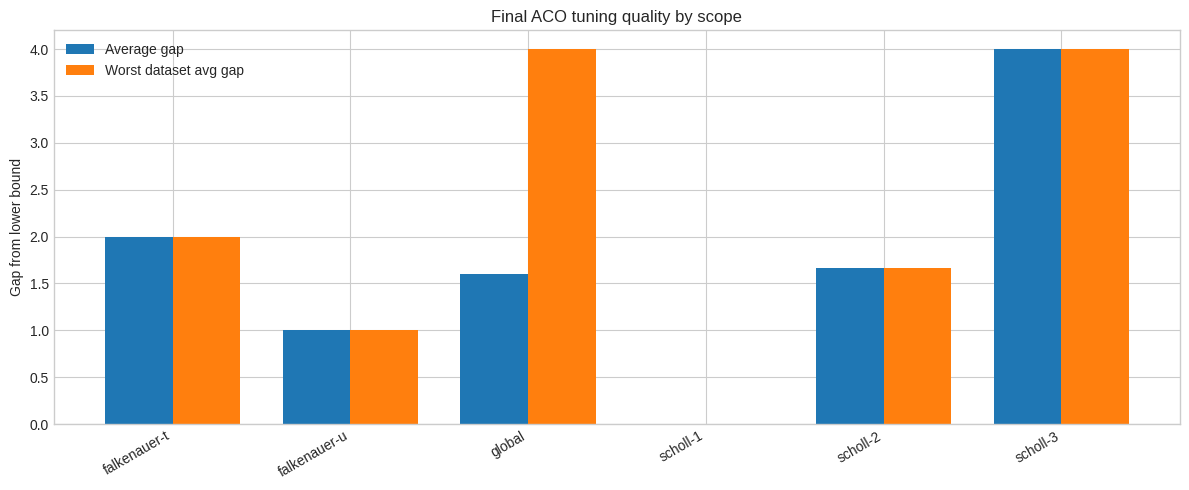

In [19]:
plot_df = final_aco_rows.sort_values("scope").reset_index(drop=True)
x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width / 2, plot_df["avg_gap"], width, label="Average gap")
ax.bar(
    x + width / 2,
    plot_df["worst_dataset_avg_gap"],
    width,
    label="Worst dataset avg gap",
)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["scope"], rotation=30, ha="right")
ax.set_ylabel("Gap from lower bound")
ax.set_title("Final ACO tuning quality by scope")
ax.legend()
savefig(fig, "aco_final_quality_by_scope.png")
plt.show()

saved results/4_population_based/aco_tuning/figures/aco_quality_runtime_tradeoff.png


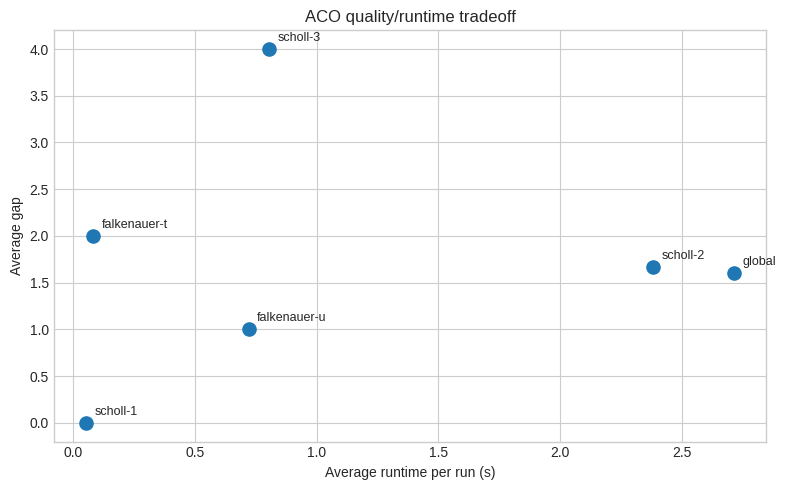

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(plot_df["avg_time"], plot_df["avg_gap"], s=90)

for _, row in plot_df.iterrows():
    ax.annotate(
        row["scope"],
        (row["avg_time"], row["avg_gap"]),
        textcoords="offset points",
        xytext=(6, 6),
        fontsize=9,
    )

ax.set_xlabel("Average runtime per run (s)")
ax.set_ylabel("Average gap")
ax.set_title("ACO quality/runtime tradeoff")
savefig(fig, "aco_quality_runtime_tradeoff.png")
plt.show()

### 4.2 Sensibilite des parametres ACO

Ces courbes montrent, pour le tuning global, l'effet de chaque valeur testee.

saved results/4_population_based/aco_tuning/figures/aco_global_parameter_curves.png


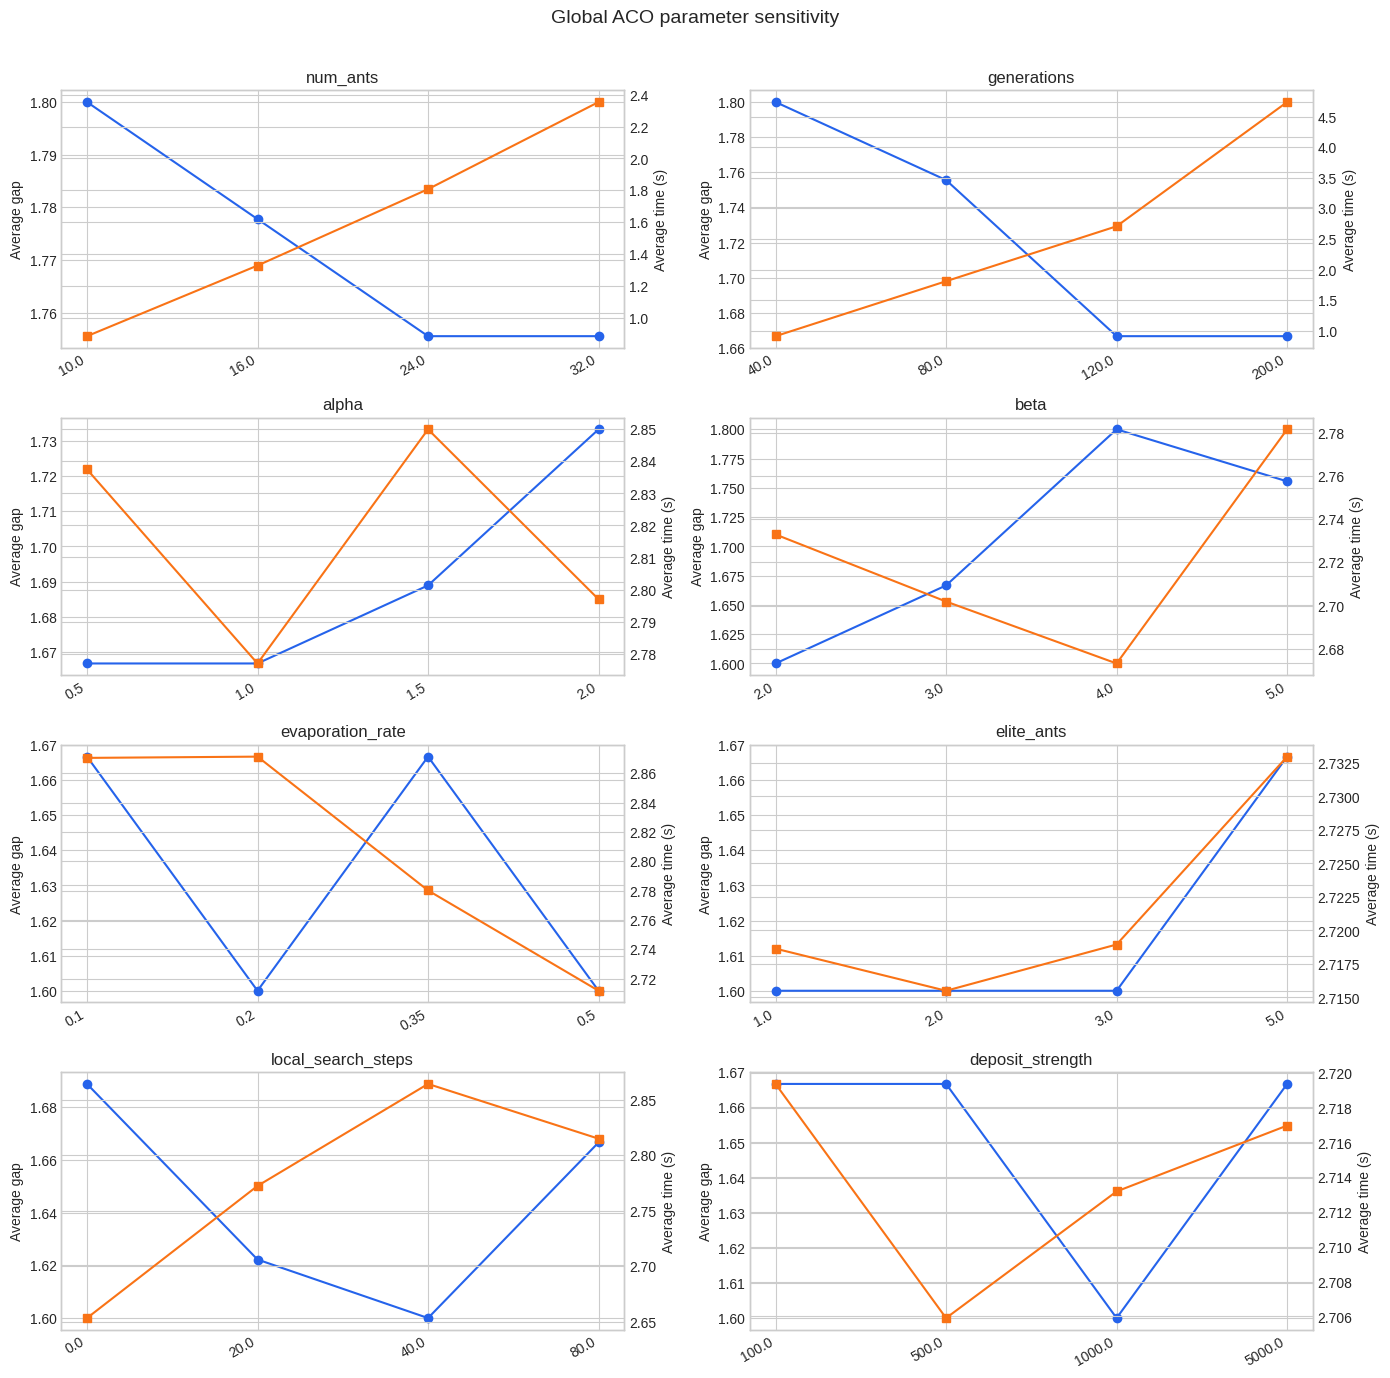

In [21]:
global_candidates = aco_logs[
    (aco_logs["scope"] == "global") & (aco_logs["parameter"] != "initial")
].copy()

parameters = list(global_candidates["parameter"].drop_duplicates())
ncols = 2
nrows = int(np.ceil(len(parameters) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, max(4, 3.4 * nrows)))
axes = np.array(axes).reshape(-1)

for ax, parameter in zip(axes, parameters):
    data = global_candidates[global_candidates["parameter"] == parameter].copy()
    data = data.reset_index(drop=True)
    xs = np.arange(len(data))
    labels = data["value"].astype(str).tolist()

    ax.plot(xs, data["avg_gap"], marker="o", color="#2563eb", label="avg gap")
    ax.set_xticks(xs)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_title(parameter)
    ax.set_ylabel("Average gap")

    ax2 = ax.twinx()
    ax2.plot(xs, data["avg_time"], marker="s", color="#f97316", label="avg time")
    ax2.set_ylabel("Average time (s)")

for ax in axes[len(parameters):]:
    ax.axis("off")

fig.suptitle("Global ACO parameter sensitivity", fontsize=14, y=1.01)
savefig(fig, "aco_global_parameter_curves.png")
plt.show()

saved results/4_population_based/aco_tuning/figures/aco_selected_tuning_path.png


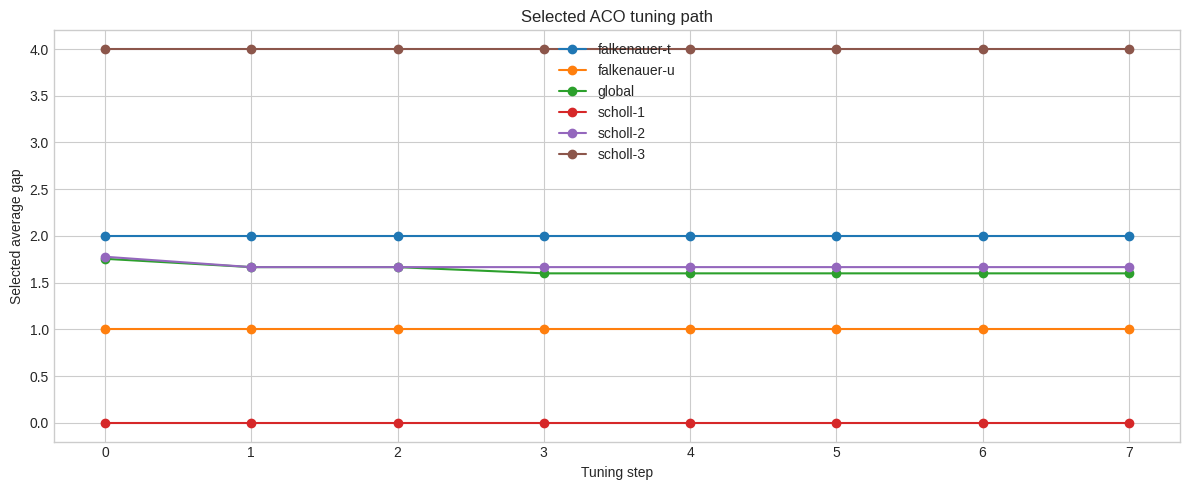

,scope,round,parameter,value,avg_gap,worst_dataset_avg_gap,exact_hits,avg_time
0,falkenauer-t,1,num_ants,10.00,2.000,2.000,0,0.199
1,falkenauer-t,1,generations,40.00,2.000,2.000,0,0.100
2,falkenauer-t,1,alpha,2.00,2.000,2.000,0,0.099
3,falkenauer-t,1,beta,5.00,2.000,2.000,0,0.098
4,falkenauer-t,1,evaporation_rate,0.50,2.000,2.000,0,0.097
5,falkenauer-t,1,elite_ants,1.00,2.000,2.000,0,0.097
6,falkenauer-t,1,local_search_steps,0.00,2.000,2.000,0,0.084
7,falkenauer-t,1,deposit_strength,5000.00,2.000,2.000,0,0.084
8,falkenauer-u,1,num_ants,10.00,1.000,1.000,0,1.541
9,falkenauer-u,1,generations,40.00,1.000,1.000,0,0.808


In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
for scope, group in selected_steps.groupby("scope"):
    group = group.reset_index(drop=True)
    xs = np.arange(len(group))
    ax.plot(xs, group["avg_gap"], marker="o", label=scope)

ax.set_xlabel("Tuning step")
ax.set_ylabel("Selected average gap")
ax.set_title("Selected ACO tuning path")
ax.legend()
savefig(fig, "aco_selected_tuning_path.png")
plt.show()

display(
    selected_steps[
        ["scope", "round", "parameter", "value", "avg_gap",
         "worst_dataset_avg_gap", "exact_hits", "avg_time"]
    ].round({
        "avg_gap": 3,
        "worst_dataset_avg_gap": 3,
        "avg_time": 3,
    })
)

,num_ants,generations,alpha,beta,evaporation_rate,elite_ants,local_search_steps,deposit_strength
scope,,,,,,,,
falkenauer-t,10,40,2.0,5.0,0.50,1,0,5000.0
falkenauer-u,10,40,0.5,5.0,0.35,3,0,100.0
global,24,120,1.0,2.0,0.50,2,40,1000.0
scholl-1,10,40,2.0,5.0,0.50,1,0,1000.0
scholl-2,24,120,0.5,3.0,0.20,1,40,1000.0
scholl-3,10,40,1.0,5.0,0.50,1,0,1000.0


saved results/4_population_based/aco_tuning/figures/aco_selected_parameter_heatmap.png


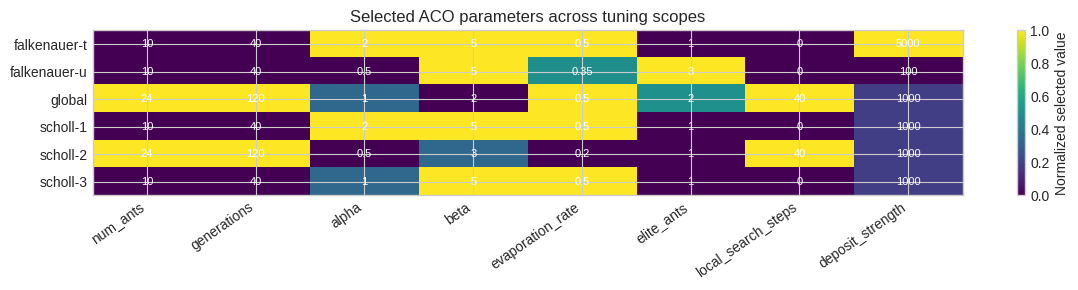

In [23]:
param_table = final_aco_rows.set_index("scope")[TUNED_PARAM_COLS].sort_index()
display(param_table)

mins = param_table.min(axis=0)
maxs = param_table.max(axis=0)
denom = (maxs - mins).replace(0, 1)
normalized = (param_table - mins) / denom

fig, ax = plt.subplots(figsize=(12, max(3, 0.5 * len(normalized))))
im = ax.imshow(normalized, aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(TUNED_PARAM_COLS)))
ax.set_xticklabels(TUNED_PARAM_COLS, rotation=35, ha="right")
ax.set_yticks(np.arange(len(normalized.index)))
ax.set_yticklabels(normalized.index)
ax.set_title("Selected ACO parameters across tuning scopes")

for i in range(param_table.shape[0]):
    for j in range(param_table.shape[1]):
        value = param_table.iloc[i, j]
        ax.text(j, i, f"{value:g}", ha="center", va="center", color="white", fontsize=8)

fig.colorbar(im, ax=ax, label="Normalized selected value")
savefig(fig, "aco_selected_parameter_heatmap.png")
plt.show()

---

## 5) Comparaison GA vs ACO

Cette section compare les deux familles d'algorithmes population-based.

Le notebook lit `results/4_population_based/aco_tuning/population_comparison.csv`. Si ce
fichier n'existe pas, il le construit avec un workload compact. Cela permet de
garder les resultats reutilisables pour les figures.

Par defaut, la variante `ga memetic` n'est pas incluse dans cette generation
automatique car elle est nettement plus lente. Vous pouvez l'activer en mettant
`INCLUDE_MEMETIC = True`.

In [24]:
DATASET_PATHS = {
    "falkenauer-t": PROJECT_ROOT / "benchmarks" / "Falkenauer" / "Falkenauer_T",
    "falkenauer-u": PROJECT_ROOT / "benchmarks" / "Falkenauer" / "Falkenauer U",
    "scholl-1": PROJECT_ROOT / "benchmarks" / "Scholl" / "Scholl_1",
    "scholl-2": PROJECT_ROOT / "benchmarks" / "Scholl" / "Scholl_2",
    "scholl-3": PROJECT_ROOT / "benchmarks" / "Scholl" / "Scholl_3",
}

COMPARISON_CSV = RESULTS_BASE_DIR / "population_comparison.csv"
COMPARISON_DATASETS = ["falkenauer-t", "falkenauer-u", "scholl-1", "scholl-2", "scholl-3"]
COMPARISON_MAX_ITEMS = 250
COMPARISON_MAX_PER_SIZE = 1
COMPARISON_SEEDS = [0]
INCLUDE_MEMETIC = False
FORCE_REBUILD_COMPARISON = False


def parse_instance_file(path, dataset):
    lines = path.read_text(encoding="utf-8").splitlines()
    n = int(lines[0])
    capacity = int(lines[1])
    sizes = [int(lines[i]) for i in range(2, 2 + n)]
    return {
        "dataset": dataset,
        "instance": path.stem,
        "num_items": n,
        "capacity": capacity,
        "sizes": sizes,
    }


def load_comparison_instances():
    instances = []
    for dataset in COMPARISON_DATASETS:
        by_size = {}
        for path in sorted(DATASET_PATHS[dataset].glob("*.txt")):
            inst = parse_instance_file(path, dataset)
            if COMPARISON_MAX_ITEMS is not None and inst["num_items"] > COMPARISON_MAX_ITEMS:
                continue
            by_size.setdefault(inst["num_items"], []).append(inst)
        for size in sorted(by_size):
            instances.extend(by_size[size][:COMPARISON_MAX_PER_SIZE])
    return instances


def run_method(instance, method_label, method_name, params, seed):
    random.seed(seed)
    total_weight = sum(instance["sizes"])
    lower_bound = ceil(total_weight / instance["capacity"])

    start = time.perf_counter()
    solver = BinPackingSolver(instance["sizes"], instance["capacity"])
    solver.solve(method_name, **params)
    elapsed = time.perf_counter() - start
    solution = solver.get_solution()

    bins = solution.total_bins_used
    return {
        "dataset": instance["dataset"],
        "instance": instance["instance"],
        "items": instance["num_items"],
        "capacity": instance["capacity"],
        "total_weight": total_weight,
        "seed": seed,
        "method": method_label,
        "bins": bins,
        "lower_bound": lower_bound,
        "gap": bins - lower_bound,
        "elapsed_time": elapsed,
        "fill_rate": total_weight / (bins * instance["capacity"]) * 100,
    }


def build_population_comparison_csv():
    methods = [
        ("GA", "ga", {}),
        ("GA island", "ga island", {}),
        ("ACO tuned global", "aco", global_aco_params),
    ]
    if INCLUDE_MEMETIC:
        methods.insert(1, ("GA memetic", "ga memetic", {}))

    rows = []
    instances = load_comparison_instances()
    for instance in instances:
        for seed in COMPARISON_SEEDS:
            for method_label, method_name, params in methods:
                rows.append(run_method(instance, method_label, method_name, params, seed))

    df = pd.DataFrame(rows)
    df.to_csv(COMPARISON_CSV, index=False)
    return df


if FORCE_REBUILD_COMPARISON or not COMPARISON_CSV.exists():
    print("Building population comparison CSV...")
    comparison_df = build_population_comparison_csv()
else:
    comparison_df = pd.read_csv(COMPARISON_CSV)

display(comparison_df.head())
print(f"rows: {len(comparison_df)}")
print(f"csv: {COMPARISON_CSV.relative_to(PROJECT_ROOT)}")

,dataset,instance,items,capacity,total_weight,seed,method,bins,lower_bound,gap,elapsed_time,fill_rate
0,falkenauer-t,Falkenauer_t60_00,60,1000,20000,0,GA,21,20,1,0.728084,95.238095
1,falkenauer-t,Falkenauer_t60_00,60,1000,20000,0,GA island,21,20,1,0.796094,95.238095
2,falkenauer-t,Falkenauer_t60_00,60,1000,20000,0,ACO tuned global,22,20,2,0.576288,90.909091
3,falkenauer-u,Falkenauer_u120_00,120,150,7078,0,GA,49,48,1,1.622610,96.299320
4,falkenauer-u,Falkenauer_u120_00,120,150,7078,0,GA island,49,48,1,1.979703,96.299320


rows: 24
csv: results/4_population_based/population_comparison.csv


In [25]:
method_summary = (
    comparison_df.groupby("method", as_index=False)
    .agg(
        runs=("gap", "size"),
        avg_gap=("gap", "mean"),
        max_gap=("gap", "max"),
        exact_hits=("gap", lambda s: int((s == 0).sum())),
        avg_time=("elapsed_time", "mean"),
        avg_fill_rate=("fill_rate", "mean"),
    )
    .sort_values(["avg_gap", "max_gap", "avg_time"])
    .reset_index(drop=True)
)

display(method_summary.round({
    "avg_gap": 3,
    "avg_time": 3,
    "avg_fill_rate": 2,
}))

,method,runs,avg_gap,max_gap,exact_hits,avg_time,avg_fill_rate
0,ACO tuned global,8,1.625,4,1,2.927,95.15
1,GA,8,1.750,4,1,1.611,94.73
2,GA island,8,1.875,4,1,1.981,94.56


### 5.1 Qualite moyenne par methode

saved results/4_population_based/aco_tuning/figures/population_avg_gap_by_method.png


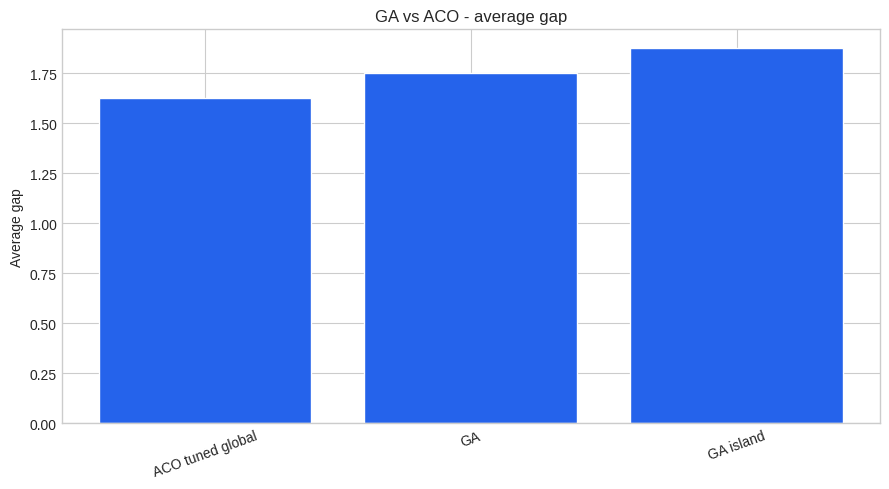

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
order = method_summary["method"].tolist()
plot_data = method_summary.set_index("method").loc[order]
ax.bar(plot_data.index, plot_data["avg_gap"], color="#2563eb", edgecolor="white")
ax.set_ylabel("Average gap")
ax.set_title("GA vs ACO - average gap")
ax.tick_params(axis="x", rotation=20)
savefig(fig, "population_avg_gap_by_method.png")
plt.show()

saved results/4_population_based/aco_tuning/figures/population_runtime_by_method.png


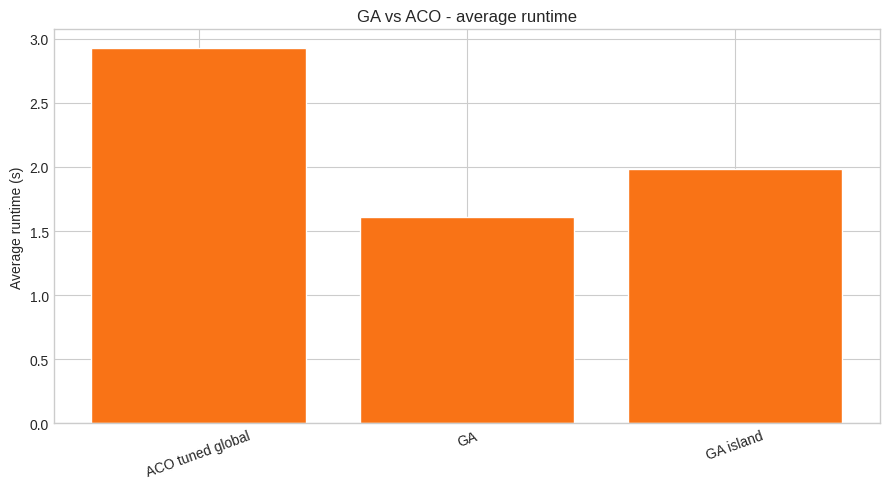

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_data.index, plot_data["avg_time"], color="#f97316", edgecolor="white")
ax.set_ylabel("Average runtime (s)")
ax.set_title("GA vs ACO - average runtime")
ax.tick_params(axis="x", rotation=20)
savefig(fig, "population_runtime_by_method.png")
plt.show()

method,ACO tuned global,GA,GA island
dataset,,,
falkenauer-t,2.000,1.000,1.000
falkenauer-u,1.000,1.000,1.000
scholl-1,0.000,0.000,0.000
scholl-2,1.667,2.333,2.667
scholl-3,4.000,4.000,4.000


saved results/4_population_based/aco_tuning/figures/population_gap_by_dataset_method.png


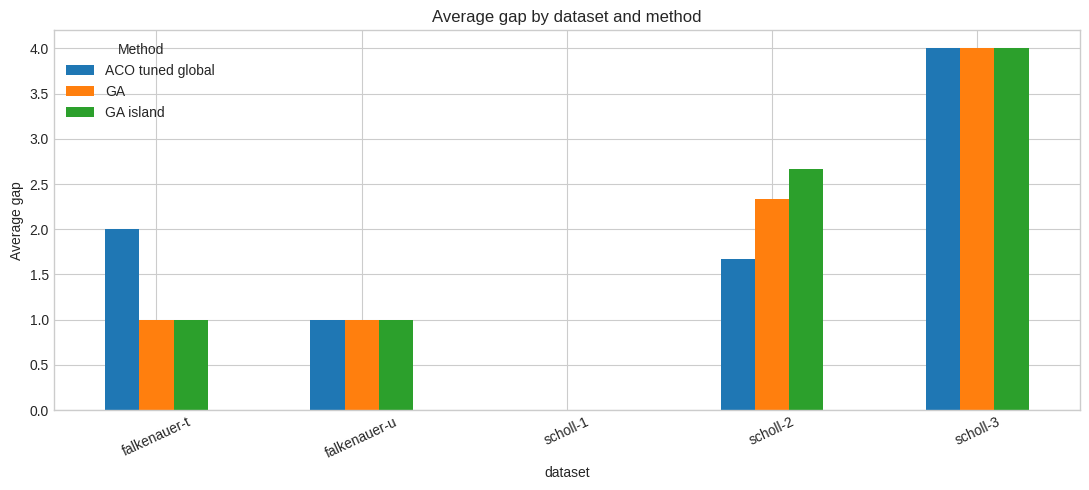

In [28]:
dataset_method = (
    comparison_df.groupby(["dataset", "method"], as_index=False)
    .agg(avg_gap=("gap", "mean"), avg_time=("elapsed_time", "mean"))
)

pivot_gap = dataset_method.pivot(index="dataset", columns="method", values="avg_gap")
display(pivot_gap.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
pivot_gap[order].plot(kind="bar", ax=ax)
ax.set_ylabel("Average gap")
ax.set_title("Average gap by dataset and method")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Method")
savefig(fig, "population_gap_by_dataset_method.png")
plt.show()

saved results/4_population_based/aco_tuning/figures/population_quality_runtime_tradeoff.png


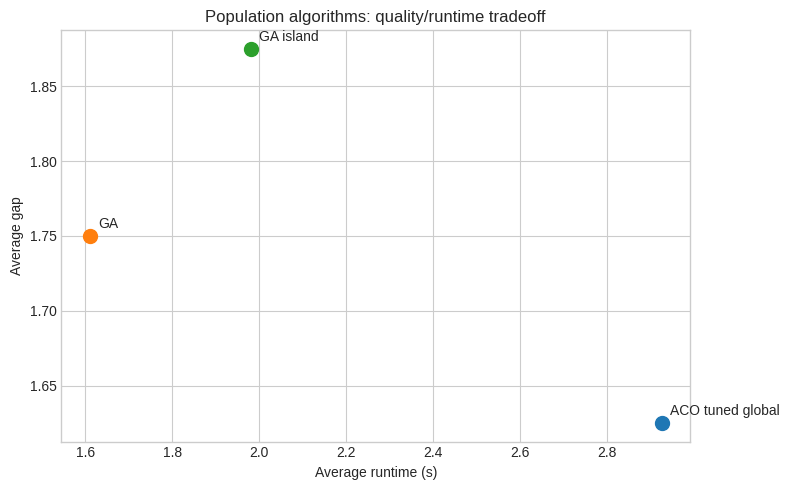

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
for method, group in method_summary.groupby("method"):
    ax.scatter(group["avg_time"], group["avg_gap"], s=100, label=method)
    row = group.iloc[0]
    ax.annotate(
        method,
        (row["avg_time"], row["avg_gap"]),
        textcoords="offset points",
        xytext=(6, 6),
    )

ax.set_xlabel("Average runtime (s)")
ax.set_ylabel("Average gap")
ax.set_title("Population algorithms: quality/runtime tradeoff")
savefig(fig, "population_quality_runtime_tradeoff.png")
plt.show()

---

## 6) Conclusion

Les CSV de tuning permettent d'expliquer pourquoi une configuration ACO est
choisie. La comparaison GA/ACO permet ensuite de verifier si ce reglage est
competitif face aux variantes genetiques.

Points a discuter dans le rapport :

- le gap moyen et le gap maximal,
- le compromis qualite/temps,
- la robustesse par famille de benchmarks,
- l'interet ou non d'utiliser des presets ACO par dataset.